# Calculate first latency pdf- probability density function of the time to first opening

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import math


In [2]:
from scalcs.samples import samples
from scalcs import firstlatency as fl
from scalcs import qmatlib as qm


##### Load Colquhoun, Hawkes, Merlushkin \& Edmonds 1997 numerical example
CHME97 is now available in `scalcs.samples.samples`.


In [3]:
from scalcs.samples.samples import CHME97


In [4]:
c0 = 0.0 # 0 mM
c1 = 0.001 # 1 mM
mec0 = CHME97()
mec0.set_eff('c', c0)
mec1 = CHME97()
mec1.set_eff('c', c1)

##### Helper functions are now in `scalcs.firstlatency`
Ideal, asymptotic and exact first-latency pdfs are implemented in
`scalcs/firstlatency.py` and imported above as `fl`.


In [5]:
# Helper functions (asymptotic_areas_first_latency, asymptotic_pdf,
# exact_GAMAxx) have been moved to scalcs/firstlatency.py.
# Use fl.asymptotic_roots, fl.asymptotic_areas, fl.asymptotic_pdf,
# fl.gamma_coefficients and fl.exact_pdf below.


#### The special case of a simple step from zero concentration

In [6]:
points = 512
tstart = 1.0e-6 
tend = 0.1
tseq = np.logspace(math.log10(tstart), math.log10(tend), points)

In [7]:
tres = 0.001  # 1 ms
phi_shut = qm.pinf(mec0.Q)[mec0.kA:]


In [8]:
# Ideal first-latency pdf (no missed events)
eigs, areas_ideal = fl.ideal_components(mec1.QFF, phi_shut)
ipdf = fl.ideal_pdf(tseq, mec1.QFF, phi_shut)
print("Ideal: {} components".format(mec1.kF))
print("  eigenvalues (1/s): {}".format(eigs))
print("  areas (sum={:.6f}): {}".format(areas_ideal.sum(), areas_ideal))


Ideal: 4 components
  eigenvalues (1/s): [1.51674995e+00 5.50790369e+01 5.00480416e+03 1.00094000e+04]
  areas (sum=1.000000): [ 0.1618908   0.85219925 -0.01875259  0.00466253]


In [9]:
# Asymptotic first-latency pdf (HJC correction for missed events)
roots = fl.asymptotic_roots(tres, mec1)
areas_asym = fl.asymptotic_areas(tres, roots, phi_shut, mec1)
tau = -1.0 / roots
apdf = fl.asymptotic_pdf(tseq, tres, tau, areas_asym)
print("Asymptotic roots: {}".format(roots))
print("Asymptotic areas (sum={:.6f}): {}".format(areas_asym.sum(), areas_asym))


Asymptotic roots: [-1.00093929e+04 -5.00376120e+03 -2.72234212e+01 -1.21339307e+00]
Asymptotic areas (sum=0.999150): [ 3.59205712e-04 -6.67693508e-03  6.64249047e-01  3.41218543e-01]


In [10]:
# Exact first-latency pdf (HJC: tres <= t <= 3*tres corrected, asymptotic beyond)
eigvals, g00, g10, g11 = fl.gamma_coefficients(tres, phi_shut, mec1)
epdf = fl.exact_pdf(tseq, tres, roots, areas_asym, eigvals, g00, g10, g11)


red dashed- ideal pdf; blue dashed- asymptotic pdf; blue solid- exact + asymptotic pdf


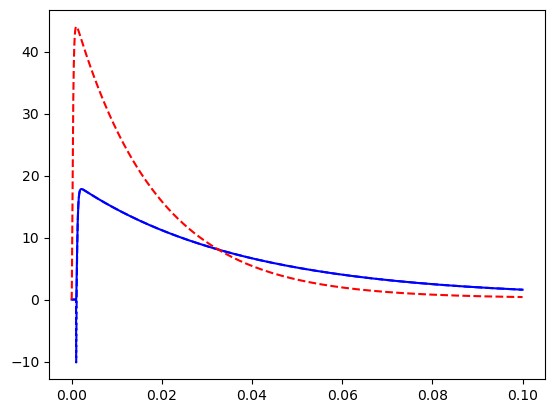

In [11]:
plt.plot(tseq, apdf, 'b--');
plt.plot(tseq, epdf, 'b-');
plt.plot(tseq, ipdf, 'r--');
print('red dashed- ideal pdf; blue dashed- asymptotic pdf; blue solid- exact + asymptotic pdf')

red dashed- ideal pdf; blue dashed- asymptotic pdf; blue solid- exact + asymptotic pdf


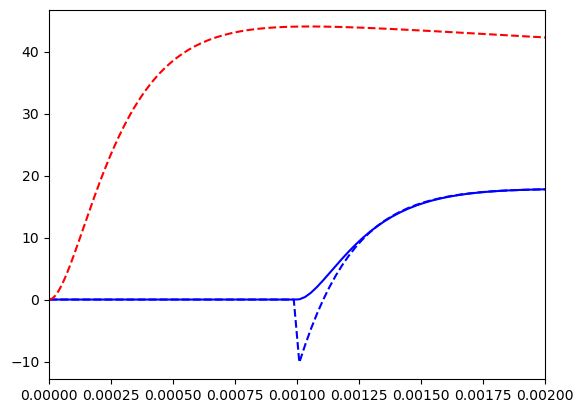

In [12]:
plt.plot(tseq, apdf, 'b--');
plt.plot(tseq, epdf, 'b-');
plt.plot(tseq, ipdf, 'r--');
plt.xlim([0.0, 0.002]);
print('red dashed- ideal pdf; blue dashed- asymptotic pdf; blue solid- exact + asymptotic pdf')